#Name : Saksham Sigdel
##STD ID : 2418223
###Worksheet 6

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task 1: Improve the CNN Model From Worksheet 5

Repeat the tasks from Worksheet 5, but improve the CNN model using the same fruit dataset.

Tasks:
- check the dataset folders
- check corrupted images
- count class balance
- visualize random images
- use data augmentation
- build a deeper CNN using Batch Normalization and Dropout
- train, evaluate, save the model, and make a classification report

Checking path: /content/drive/MyDrive/Ai/FruitinAmazon/train

Found 6 classes:
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Image Check Summary
Corrupted removed: 0
Skipped files: 0

Class Distribution
Class                    Count
acai                        15
cupuacu                     15
graviola                    15
guarana                     15
pupunha                     15
tucuma                      15


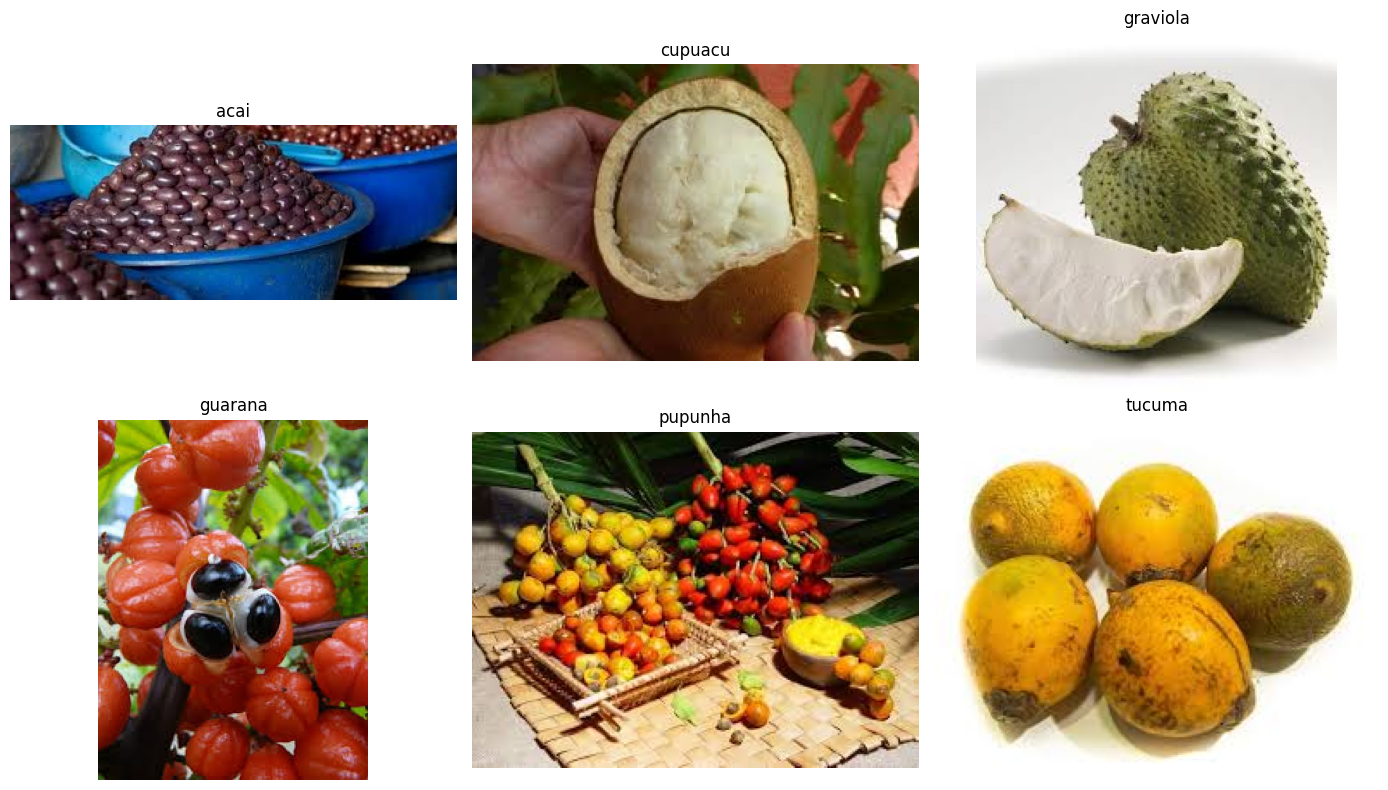

In [6]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from google.colab import drive



# =========================
# 2. Correct Paths (FIXED)
# =========================
project_dir = '/content/drive/MyDrive/Ai/FruitinAmazon'

# dataset_dir = os.path.join(project_dir, 'FruitinAmazon')

# ✅ USE THIS (CORRECT)
train_dir = os.path.join(project_dir, 'train')
test_dir = os.path.join(project_dir, 'test')

# =========================
# 3. Valid Extensions
# =========================
valid_ext = ('.png', '.jpg', '.jpeg')

# =========================
# 4. Check Directory
# =========================
print("Checking path:", train_dir)

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Train directory not found: {train_dir}")

# =========================
# 5. Get Class Folders
# =========================
class_names = sorted([
    name for name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, name))
])

if len(class_names) == 0:
    print('No class directories found in the train folder!')
else:
    print(f'\nFound {len(class_names)} classes:')
    print(class_names)

# =========================
# 6. Check Corrupted Images
# =========================
corrupted_images = []
skipped_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        if not img_name.lower().endswith(valid_ext):
            continue

        if not os.path.exists(img_path):
            skipped_images.append(img_path)
            continue

        try:
            with Image.open(img_path) as img:
                img.load()

        except UnidentifiedImageError:
            corrupted_images.append(img_path)
            print(f'Corrupted image: {img_path}')
            if os.path.exists(img_path):
                os.remove(img_path)

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            print(f'Unreadable image: {img_path}')
            if os.path.exists(img_path):
                os.remove(img_path)

        except OSError as e:
            skipped_images.append(img_path)
            print(f'Skipped (Drive issue): {img_path}')

# =========================
# 7. Summary
# =========================
print('\nImage Check Summary')
print('=' * 40)
print(f'Corrupted removed: {len(corrupted_images)}')
print(f'Skipped files: {len(skipped_images)}')
print('=' * 40)

# =========================
# 8. Class Distribution
# =========================
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(valid_ext)
    ]
    class_counts[class_name] = len(images)

print('\nClass Distribution')
print('=' * 40)
print(f"{'Class':<20}{'Count':>10}")
print('=' * 40)

for class_name, count in class_counts.items():
    print(f"{class_name:<20}{count:>10}")

print('=' * 40)

# =========================
# 9. Show Sample Images
# =========================
random.seed(42)

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(valid_ext)
    ]

    if len(images) > 0:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

# Plot
num_images = len(selected_images)
cols = 3
rows = (num_images + cols - 1) // cols

plt.figure(figsize=(14, 4 * rows))

for i, image_path in enumerate(selected_images):
    plt.subplot(rows, cols, i + 1)

    try:
        with Image.open(image_path) as img:
            plt.imshow(img)
        plt.title(selected_labels[i])
        plt.axis('off')

    except Exception as e:
        plt.text(0.5, 0.5, 'Error loading image', ha='center')
        plt.title(selected_labels[i])
        plt.axis('off')
        print(f'Error displaying: {image_path}')

plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# using 224 by 224 because it also works well for transfer learning later
img_height = 224
img_width = 224
image_size = (img_height, img_width)
batch_size = 16
validation_split = 0.2
seed = 1337

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset='training',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset='validation',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print('Class names:', class_names)
print('Number of classes:', num_classes)

for images, labels in train_ds.take(1):
    print('Images shape:', images.shape)
    print('Labels shape:', labels.shape)

# prefetch makes loading a bit faster while training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Images shape: (16, 224, 224, 3)
Labels shape: (16,)


In [9]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Activation, Dropout, Flatten, Dense

# adding augmentation so the model can see slightly changed images during training
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='data_augmentation')

scratch_model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    # first convolution block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # second convolution block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # third convolution block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # fourth convolution block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# summary helps to understand the layers and parameters
scratch_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.1625 - loss: 2.3764
Epoch 1: val_loss improved from None to 1.87016, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 784ms/step - accuracy: 0.1667 - loss: 2.4072 - val_accuracy: 0.0000e+00 - val_loss: 1.8702
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.1500 - loss: 2.3280
Epoch 2: val_loss improved from 1.87016 to 1.78044, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 590ms/step - accuracy: 0.1250 - loss: 2.3421 - val_accuracy: 0.1667 - val_loss: 1.7804
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.1267 - loss: 2.3221 
Epoch 3: val_loss did not improve from 1.78044
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.1389 - loss: 2.3283 - val_accuracy: 0.0000e+00 - val_loss: 1.7946
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.1847 - loss: 2.0580 
Epoch 4: val_loss improved from 1.78044 to 1.72493, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 461ms/step - accuracy: 0.1944 - loss: 2.1950 - val_accuracy: 0.0000e+00 - val_loss: 1.7249
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.3253 - loss: 2.0219
Epoch 5: val_loss improved from 1.72493 to 1.66316, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.3194 - loss: 1.9548 - val_accuracy: 0.0556 - val_loss: 1.6632
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.1969 - loss: 2.1110
Epoch 6: val_loss improved from 1.66316 to 1.56867, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5


...


Epoch 15: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 491ms/step - accuracy: 0.3333 - loss: 1.8157 - val_accuracy: 0.8333 - val_loss: 0.8354
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.3090 - loss: 1.7365
Epoch 16: val_loss improved from 0.83540 to 0.78123, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5



Epoch 16: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 579ms/step - accuracy: 0.3472 - loss: 1.6866 - val_accuracy: 0.8333 - val_loss: 0.7812
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.3240 - loss: 1.6917
Epoch 17: val_loss improved from 0.78123 to 0.74517, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5



Epoch 17: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2917 - loss: 1.7241 - val_accuracy: 0.8333 - val_loss: 0.7452
Epoch 18/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.3441 - loss: 1.7316
Epoch 18: val_loss improved from 0.74517 to 0.72553, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5



Epoch 18: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 580ms/step - accuracy: 0.3194 - loss: 1.8027 - val_accuracy: 0.8333 - val_loss: 0.7255
Epoch 19/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.4087 - loss: 1.6940
Epoch 19: val_loss improved from 0.72553 to 0.72338, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5



Epoch 19: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 571ms/step - accuracy: 0.3611 - loss: 1.6567 - val_accuracy: 0.8333 - val_loss: 0.7234
Epoch 20/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.3337 - loss: 1.5647
Epoch 20: val_loss did not improve from 0.72338
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.3611 - loss: 1.5692 - val_accuracy: 0.8333 - val_loss: 0.7507
Epoch 21/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5885 - loss: 1.3498
Epoch 21: val_loss did not improve from 0.72338
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.5833 - loss: 1.3645 - val_accuracy: 0.8333 - val_loss: 0.7706
Epoch 22/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3337 - loss: 1.5094
Epoch 22: val_loss did not improve from 0.72338
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.3611 - loss: 1.5309 - val_accuracy: 0.8333 - val_loss: 0.8169
Epoch 23/250
5/5 ━━━━━━━━━━━━━━━━━━━

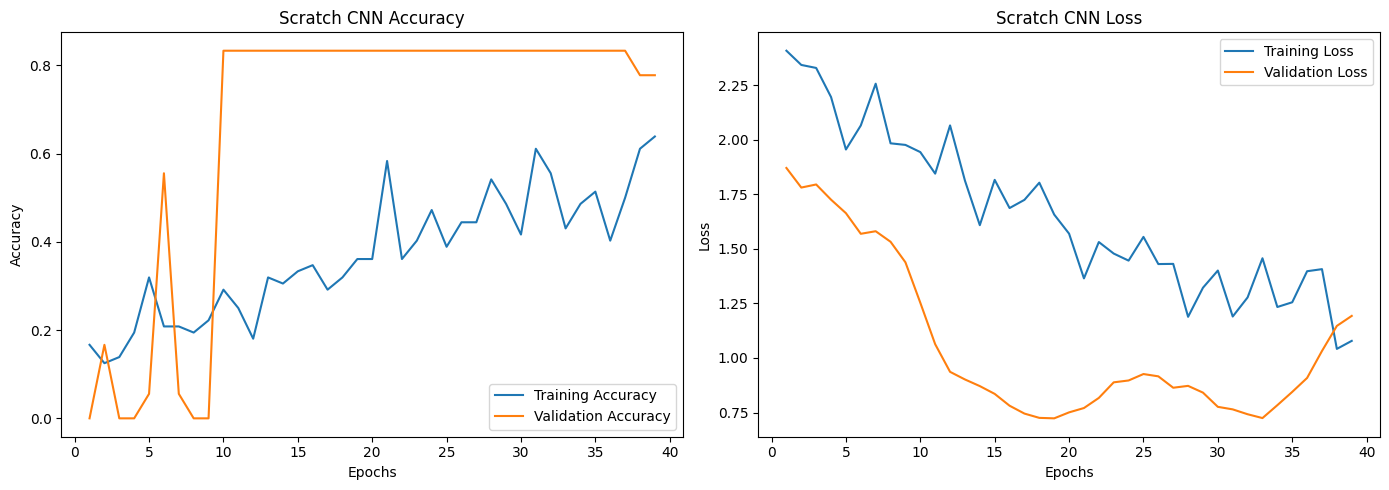

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.1667 - loss: 2.7010


Scratch CNN Test Loss: 2.7010
Scratch CNN Test Accuracy: 0.1667
Scratch CNN saved at: /content/drive/MyDrive/Ai/FruitinAmazon/week6_scratch_cnn_final.h5
Scratch CNN Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.17      1.00      0.29         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report


scratch_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

scratch_best_path = os.path.join(project_dir, 'week6_best_scratch_cnn.h5')
scratch_final_path = os.path.join(project_dir, 'week6_scratch_cnn_final.h5')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath=scratch_best_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# training the improved CNN model
scratch_history = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[early_stop, checkpoint]
)

# plotting accuracy and loss to see training behavior
acc = scratch_history.history['accuracy']
val_acc = scratch_history.history['val_accuracy']
loss = scratch_history.history['loss']
val_loss = scratch_history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Scratch CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Scratch CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# evaluating the scratch CNN model
scratch_test_loss, scratch_test_accuracy = scratch_model.evaluate(test_ds)
print(f'Scratch CNN Test Loss: {scratch_test_loss:.4f}')
print(f'Scratch CNN Test Accuracy: {scratch_test_accuracy:.4f}')

scratch_model.save(scratch_final_path)
print(f'Scratch CNN saved at: {scratch_final_path}')

# classification report for scratch CNN
scratch_true_labels = []
scratch_predicted_labels = []

for images, labels in test_ds:
    predictions = scratch_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    scratch_true_labels.extend(labels.numpy())
    scratch_predicted_labels.extend(predicted_classes)

print('Scratch CNN Classification Report:\n')
print(classification_report(scratch_true_labels, scratch_predicted_labels, target_names=class_names, zero_division=0))

## Task 1 Answer: Model Summary and Training Behavior

The CNN model was made bigger and deeper with special techniques like BatchNormalization and Dropout. But it still failed badly — only 16.67% accuracy. It was so confused that it just predicted the same class (tucuma) for every image.
The reason is simple — the dataset only has 15 images per class. A big model needs thousands of images to learn properly. With so little data, it just guessed one class for everything.

## Task 2: Transfer Learning Using VGG16

Implement transfer learning using a pre-trained model trained on ImageNet weights. Freeze the layers of VGG16 and train only the custom classification layers for the fruits dataset.

Tasks:
- load VGG16 without its top classification layer
- freeze the VGG16 layers
- add my own output layers for the 6 fruit classes
- train the model
- evaluate it and generate inference output
- make a classification report
- compare it with the CNN trained from scratch

In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# VGG16 needs its own preprocessing, so I am making separate datasets for it
vgg_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset='training',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=True
)

vgg_val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset='validation',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=False
)

vgg_test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=False
)

# applying the VGG16 preprocessing function
vgg_train_ds = vgg_train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=AUTOTUNE)
vgg_val_ds = vgg_val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=AUTOTUNE)
vgg_test_ds = vgg_test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=AUTOTUNE)

# loading VGG16 without the original classifier part
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

# freezing the VGG16 layers, so only my new layers train
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=outputs)

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 164,998 (644.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2441 - loss: 16.4070  
Epoch 1: val_loss improved from None to 7.43974, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2361 - loss: 14.1125 - val_accuracy: 0.1111 - val_loss: 7.4397
Epoch 2/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.2305 - loss: 11.8179 
Epoch 2: val_loss improved from 7.43974 to 5.51359, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.2222 - loss: 12.5197 - val_accuracy: 0.2222 - val_loss: 5.5136
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.1618 - loss: 10.7937
Epoch 3: val_loss improved from 5.51359 to 4.34254, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.1528 - loss: 10.2901 - val_accuracy: 0.2778 - val_loss: 4.3425
Epoch 4/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.2331 - loss: 10.1458
Epoch 4: val_loss improved from 4.34254 to 3.29534, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - accuracy: 0.2222 - loss: 9.8707 - val_accuracy: 0.2778 - val_loss: 3.2953
Epoch 5/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2630 - loss: 6.7798
Epoch 5: val_loss improved from 3.29534 to 2.71531, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5


...


Epoch 28: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.5694 - loss: 2.3837 - val_accuracy: 0.7778 - val_loss: 1.2012
Epoch 29/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6889 - loss: 1.7065 
Epoch 29: val_loss improved from 1.20118 to 1.18953, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5



Epoch 29: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - accuracy: 0.6528 - loss: 1.8943 - val_accuracy: 0.7778 - val_loss: 1.1895
Epoch 30/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5715 - loss: 2.1253
Epoch 30: val_loss improved from 1.18953 to 1.15559, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5



Epoch 30: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.5556 - loss: 2.4959 - val_accuracy: 0.7778 - val_loss: 1.1556
Epoch 31/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7083 - loss: 1.3577
Epoch 31: val_loss improved from 1.15559 to 1.12235, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5



Epoch 31: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.6806 - loss: 1.4607 - val_accuracy: 0.7778 - val_loss: 1.1223
Epoch 32/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6639 - loss: 2.4229 
Epoch 32: val_loss improved from 1.12235 to 1.12005, saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5



Epoch 32: finished saving model to /content/drive/MyDrive/Ai/FruitinAmazon/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.6111 - loss: 2.4985 - val_accuracy: 0.8333 - val_loss: 1.1200
Epoch 33/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6680 - loss: 1.5602
Epoch 33: val_loss did not improve from 1.12005
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.6944 - loss: 1.3392 - val_accuracy: 0.8333 - val_loss: 1.1221
Epoch 34/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6392 - loss: 2.0649
Epoch 34: val_loss did not improve from 1.12005
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.6389 - loss: 1.9841 - val_accuracy: 0.8333 - val_loss: 1.1256
Epoch 35/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7096 - loss: 1.4301 
Epoch 35: val_loss did not improve from 1.12005
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.6528 - loss: 1.8566 - val_accuracy: 0.8333 - val_loss: 1.1278
Epoch 36/50
5/5 ━━━━━━━━━━━━━━━

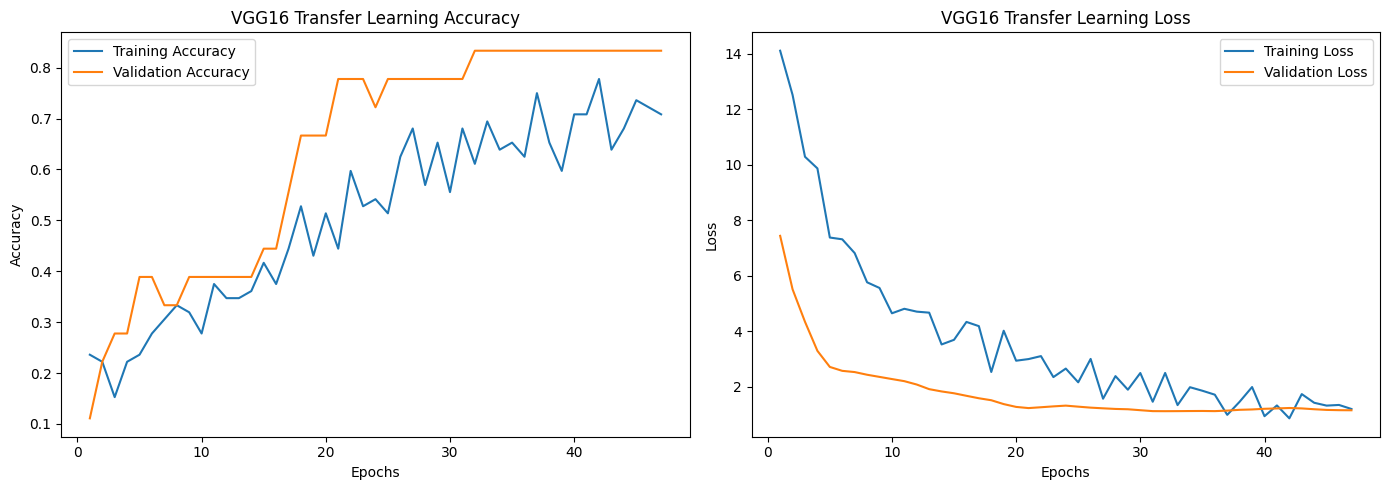

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.7333 - loss: 1.0181


VGG16 Test Loss: 1.0181
VGG16 Test Accuracy: 0.7333
VGG16 transfer model saved at: /content/drive/MyDrive/Ai/FruitinAmazon/week6_vgg16_transfer_model_final.h5
VGG16 Classification Report:

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.67      0.80      0.73         5
    graviola       1.00      0.60      0.75         5
     guarana       0.56      1.00      0.71         5
     pupunha       0.83      1.00      0.91         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.80      0.73      0.72        30
weighted avg       0.80      0.73      0.72        30


Some inference outputs:
Image 1: Predicted = acai, Actual = acai
Image 2: Predicted = guarana, Actual = acai
Image 3: Predicted = acai, Actual = acai
Image 4: Predicted = acai, Actual = acai
Image 5: Predicted = guarana, Actual = acai
Image 6: Predicted = cupuacu, Ac

In [12]:
vgg_best_path = os.path.join(project_dir, 'week6_best_vgg16_transfer_model.h5')
vgg_final_path = os.path.join(project_dir, 'week6_vgg16_transfer_model_final.h5')

vgg_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

vgg_checkpoint = ModelCheckpoint(
    filepath=vgg_best_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# training only the custom layers on top of VGG16
vgg_history = vgg_model.fit(
    vgg_train_ds,
    validation_data=vgg_val_ds,
    epochs=50,
    callbacks=[vgg_early_stop, vgg_checkpoint]
)

# plotting training behavior for transfer learning model
vgg_acc = vgg_history.history['accuracy']
vgg_val_acc = vgg_history.history['val_accuracy']
vgg_loss = vgg_history.history['loss']
vgg_val_loss = vgg_history.history['val_loss']
vgg_epochs_range = range(1, len(vgg_acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(vgg_epochs_range, vgg_acc, label='Training Accuracy')
plt.plot(vgg_epochs_range, vgg_val_acc, label='Validation Accuracy')
plt.title('VGG16 Transfer Learning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vgg_epochs_range, vgg_loss, label='Training Loss')
plt.plot(vgg_epochs_range, vgg_val_loss, label='Validation Loss')
plt.title('VGG16 Transfer Learning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# evaluating the transfer learning model
vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(vgg_test_ds)
print(f'VGG16 Test Loss: {vgg_test_loss:.4f}')
print(f'VGG16 Test Accuracy: {vgg_test_accuracy:.4f}')

vgg_model.save(vgg_final_path)
print(f'VGG16 transfer model saved at: {vgg_final_path}')

# classification report for VGG16 transfer learning
vgg_true_labels = []
vgg_predicted_labels = []

for images, labels in vgg_test_ds:
    predictions = vgg_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    vgg_true_labels.extend(labels.numpy())
    vgg_predicted_labels.extend(predicted_classes)

print('VGG16 Classification Report:\n')
print(classification_report(vgg_true_labels, vgg_predicted_labels, target_names=class_names, zero_division=0))

# showing inference output for some test images
print('\nSome inference outputs:')
for i in range(min(10, len(vgg_predicted_labels))):
    actual = class_names[int(vgg_true_labels[i])]
    predicted = class_names[int(vgg_predicted_labels[i])]
    print(f'Image {i + 1}: Predicted = {predicted}, Actual = {actual}')

# comparing both models using test accuracy
print('\nModel Accuracy Comparison:')
print(f'Scratch CNN Accuracy: {scratch_test_accuracy:.4f}')
print(f'VGG16 Transfer Learning Accuracy: {vgg_test_accuracy:.4f}')

if vgg_test_accuracy > scratch_test_accuracy:
    print('VGG16 performed better than the CNN trained from scratch.')
elif vgg_test_accuracy < scratch_test_accuracy:
    print('The CNN trained from scratch performed better in this run.')
else:
    print('Both models got the same test accuracy in this run.')

## Task 2 Answer: Did the performance improve compared to training from scratch?

VGG16 is a model that was already trained on millions of images before. We just removed its last layer, froze all its layers so they don't change, and added our own small classification layer on top.
Result — 73.33% accuracy. Much better than the scratch CNN's 16.67%.
It worked because VGG16 already knew how to see and understand images. We just told it "now classify these 6 fruits" — and since it already knew the basics, even our small dataset was enough.
Best performing class was pupunha (91% F1). Worst was tucuma (57% F1).
Overall, VGG16 was also better than Worksheet 5's model (66.67%), making it the best result so far.